In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, scipy.stats as stats

from sklearn.decomposition import PCA
from matplotlib.colors import Normalize

# sns.set(context='talk')
%matplotlib widget
# %matplotlib inline

### load

In [2]:
pca_df = pd.read_csv('../../results/pca_df.csv')
pca_df.head()

,boundary,boundary_label,stim,stim_idx,unique_stim_idx,class,PC1,PC2,PC3
0,0.25,b=0.25,0.047619,0,0,0.0,-0.343129,-0.006083,0.023421
1,0.25,b=0.25,0.047619,1,0,0.0,-0.343129,-0.006083,0.023421
2,0.25,b=0.25,0.095238,2,1,0.0,-0.328170,-0.001651,0.013417
3,0.25,b=0.25,0.095238,3,1,0.0,-0.328171,-0.001652,0.013417
4,0.25,b=0.25,0.142857,4,2,0.0,-0.306723,0.002879,0.007066


In [3]:
beh_df      = pd.read_csv('../../results/beh_df.csv')
beh_df.head()

,boundary,boundary_label,stim,stim_idx,unique_stim_idx,class,resp,class_pred,net_idx,stim_aligned,resp_aligned
0,0.25,b=0.25,0.047619,0,0,0.0,0.169804,0.0,0,-0.202381,-0.080196
1,0.25,b=0.25,0.047619,1,0,0.0,0.169804,0.0,0,-0.202381,-0.080196
2,0.25,b=0.25,0.095238,2,1,0.0,0.182941,0.0,0,-0.154762,-0.067059
3,0.25,b=0.25,0.095238,3,1,0.0,0.182941,0.0,0,-0.154762,-0.067059
4,0.25,b=0.25,0.142857,4,2,0.0,0.196852,0.0,0,-0.107143,-0.053148


In [4]:
hidden_stack = np.load('../../results/hidden_stack.npy')
print(f'hidden_stack shape: {hidden_stack.shape}')  # (n_nets, 60, 10)
hidden_mean = hidden_stack.mean(axis=0)  # [60, 10]
print(f'hidden_mean shape: {hidden_mean.shape}')

boundaries = tuple(sorted(pca_df['boundary'].unique()))
print(f'boundaries: {boundaries}')

hidden_stack shape: (30, 60, 10)
hidden_mean shape: (60, 10)
boundaries: (np.float64(0.25), np.float64(0.5), np.float64(0.75))


## Single-Unit

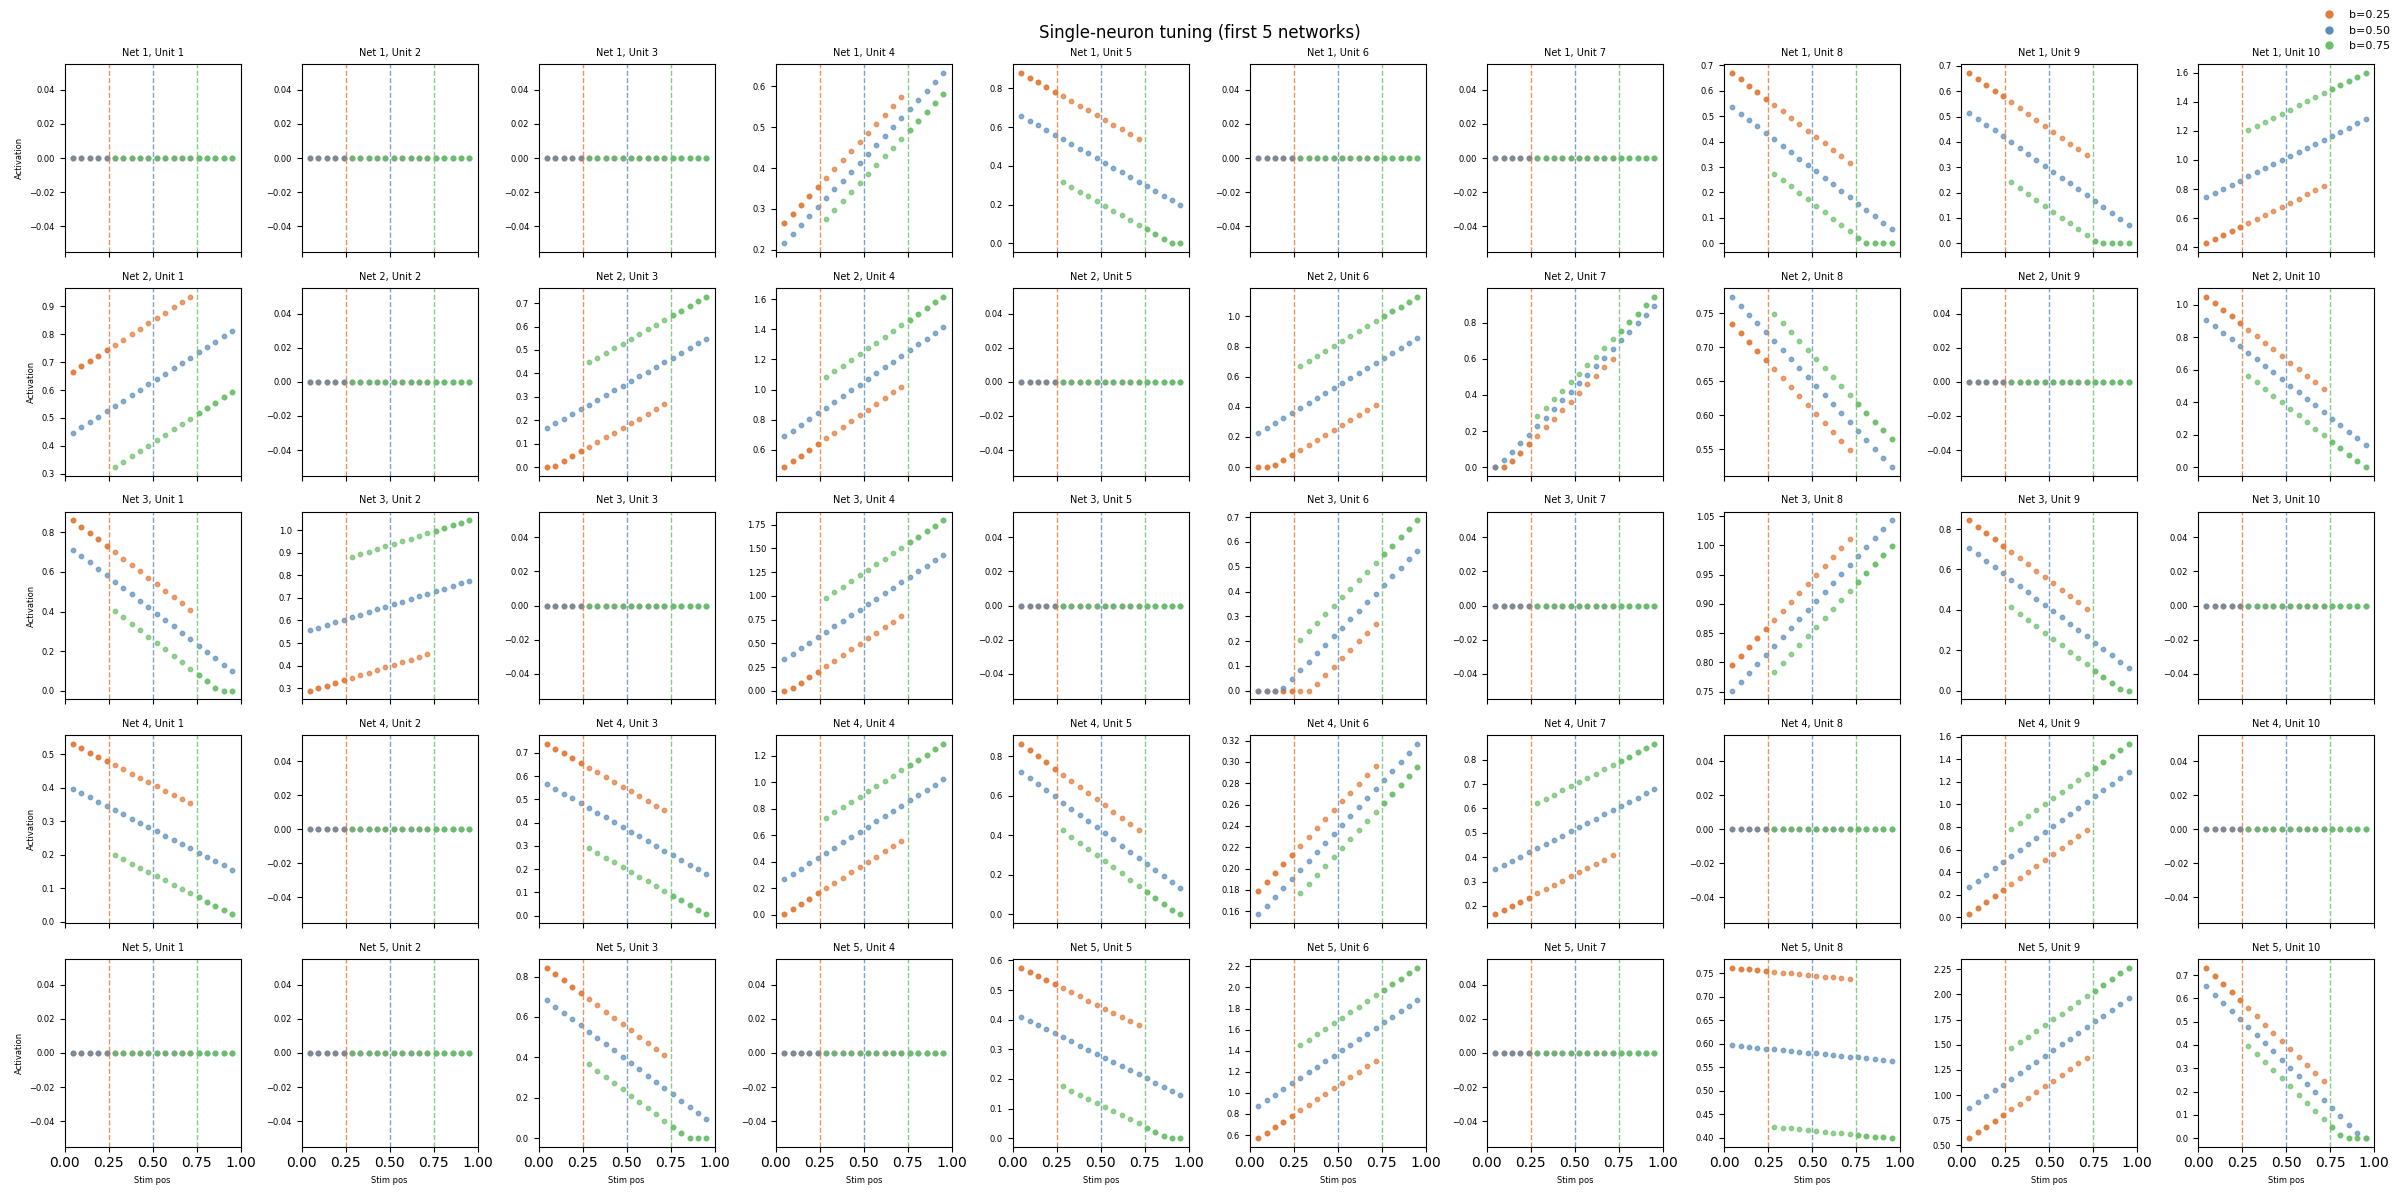

In [5]:
# Plot all neurons (no averaging) in a grid, with user-defined number of networks
n_nets_to_plot = 5  # Change this to plot a different number of networks

n_nets, n_trials, n_units = hidden_stack.shape
all_neurons = hidden_stack[:n_nets_to_plot].transpose(0, 2, 1).reshape(-1, n_trials)  # shape: (n_nets_to_plot*n_units, 60)

cond_colors = {0.25: '#e07b39', 0.50: '#5b8db8', 0.75: '#6abf69'}

# Prepare trial info for coloring
trial_info = pca_df[['boundary', 'stim']].reset_index(drop=True)

n_rows = n_nets_to_plot
n_cols = n_units
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*2.4, n_rows*2.4), sharex=True)
axes = axes.flatten()

for idx, ax in enumerate(axes):
    if idx >= all_neurons.shape[0]:
        ax.axis('off')
        continue
    neuron_act = all_neurons[idx]
    for bound in boundaries:
        mask = trial_info['boundary'] == bound
        ax.scatter(trial_info.loc[mask, 'stim'], neuron_act[mask],
                   color=cond_colors[bound], s=10, alpha=0.7)
        ax.axvline(bound, color=cond_colors[bound], linestyle='--', linewidth=1, alpha=0.8)
    ax.set_title(f'Net {idx // n_units + 1}, Unit {idx % n_units + 1}', fontsize=7)
    ax.set_xlim(0, 1)
    ax.tick_params(axis='y', labelsize=6)
    if idx % n_cols == 0:
        ax.set_ylabel('Activation', fontsize=6)
    if idx // n_cols == n_rows - 1:
        ax.set_xlabel('Stim pos', fontsize=6)

legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cond_colors[bound],
               markersize=7, label=f'b={bound:.2f}')
    for bound in boundaries
]
fig.legend(handles=legend_handles, loc='upper right', fontsize=8, frameon=False,
           bbox_to_anchor=(1.0, 1.0))
plt.suptitle(f'Single-neuron tuning (first {n_nets_to_plot} networks)')
plt.tight_layout()
plt.show()

Neuron selectivity quantification:
Type	Count	Proportion
conjunctive	13	0.043
mixed	158	0.527
class	4	0.013
context	0	0.000
non-selective	125	0.417


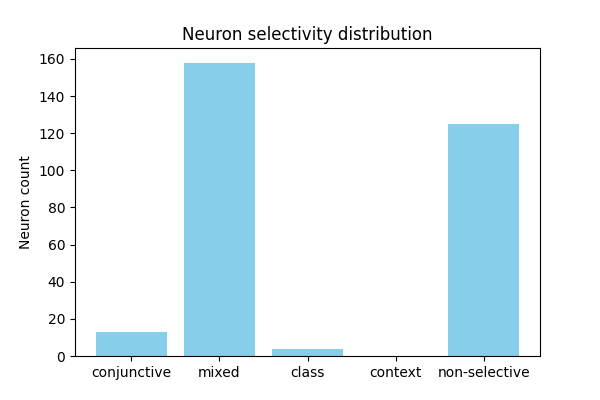

In [6]:
# --- Neuron Selectivity Quantification (robust, warnings handled) ---
import statsmodels.api as sm
from statsmodels.formula.api import ols
import warnings

# Data preparation
n_nets, n_trials, n_units = hidden_stack.shape
trial_info = pca_df[['boundary', 'class']].reset_index(drop=True)
trial_info = trial_info.rename(columns={'class': 'class_label'})

selectivity_types = ['conjunctive', 'mixed', 'class', 'context', 'non-selective']
selectivity_counts = {k: 0 for k in selectivity_types}
selectivity_assignments = []
skipped_neurons = 0

for net in range(n_nets):
    for unit in range(n_units):
        neuron_act = hidden_stack[net, :, unit]
        df = trial_info.copy()
        df['activation'] = neuron_act
        
        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                model = ols('activation ~ C(class_label) + C(boundary) + C(class_label):C(boundary)', data=df).fit()
                anova_table = sm.stats.anova_lm(model, typ=2)
            p_class = anova_table.loc['C(class_label)', 'PR(>F)']
            p_context = anova_table.loc['C(boundary)', 'PR(>F)']
            p_interaction = anova_table.loc['C(class_label):C(boundary)', 'PR(>F)']
            
            # Assign mutually exclusive category
            if p_interaction < 0.05: selectivity = 'conjunctive'
            elif p_class < 0.05 and p_context < 0.05: selectivity = 'mixed'
            elif p_class < 0.05: selectivity = 'class'
            elif p_context < 0.05: selectivity = 'context'
            else: selectivity = 'non-selective'
            
            selectivity_counts[selectivity] += 1
            selectivity_assignments.append(selectivity)
        
        except Exception as e:
            skipped_neurons += 1
            selectivity_assignments.append('skipped')
            continue

# Quantification
n_total = n_nets * n_units
selectivity_props = {k: v / n_total for k, v in selectivity_counts.items()}

# Results summary
print('Neuron selectivity quantification:')
print('Type\tCount\tProportion')
for k in selectivity_types:
    print(f'{k}\t{selectivity_counts[k]}\t{selectivity_props[k]:.3f}')
if skipped_neurons > 0:
    print(f'Skipped neurons due to model errors: {skipped_neurons}')

# Optional: Bar plot
plt.figure(figsize=(6, 4))
plt.bar(selectivity_types, [selectivity_counts[k] for k in selectivity_types], color='skyblue')
plt.ylabel('Neuron count')
plt.title('Neuron selectivity distribution')
plt.show()

### PCA on stim

In [7]:
sns.set(context='paper')
sns.set_style('white')
from matplotlib.lines import Line2D

# average hidden activations across networks for each of the 60 trials
hidden_mean = hidden_stack.mean(axis=0)  # [60, 10]

pca_df = pca_df.copy()

# raw PCA
pca = PCA(n_components=3)
pcs = pca.fit_transform(hidden_mean)
pca_df['PC1'] = pcs[:, 0]
pca_df['PC2'] = pcs[:, 1]
pca_df['PC3'] = pcs[:, 2]

# Print explained variance ratio for each PC
explained_var = pca.explained_variance_ratio_
print('Explained variance by PC:')
for i, var in enumerate(explained_var, 1):
    print(f'  PC{i}: {var*100:.2f}%')

# shared norm over global stim range
shared_norm = Normalize(vmin=pca_df['stim'].min(), vmax=pca_df['stim'].max())

# marker per condition
cond_markers = {0.25: 's', 0.50: 'o', 0.75: '^'}

# stim range common across all conditions
stim_lo, stim_hi = 0.25, 0.75

# PC-centroid-subtracted
pca3 = PCA(n_components=3)
pcs3 = pca3.fit_transform(hidden_mean)
pcs3_centered = pcs3.copy()
for bound in boundaries:
    idx = pca_df[pca_df['boundary'] == bound].index
    pcs3_centered[idx] = pcs3[idx] - pcs3[idx].mean(axis=0)
pca_df['PC1_pcc'] = pcs3_centered[:, 0]
pca_df['PC2_pcc'] = pcs3_centered[:, 1]
pca_df['PC3_pcc'] = pcs3_centered[:, 2]

# hidden-centroid-subtracted, then PCA
hidden_centered = hidden_mean.copy()
for bound in boundaries:
    idx = pca_df[pca_df['boundary'] == bound].index
    hidden_centered[idx] = hidden_mean[idx] - hidden_mean[idx].mean(axis=0)
pca2 = PCA(n_components=3)
pcs2 = pca2.fit_transform(hidden_centered)
pca_df['PC1_c'] = pcs2[:, 0]
pca_df['PC2_c'] = pcs2[:, 1]
pca_df['PC3_c'] = pcs2[:, 2]

# view angle
view_elev = 24
view_azim = -65

print('PCA setup done.')

Explained variance by PC:
  PC1: 98.33%
  PC2: 1.48%
  PC3: 0.17%
PCA setup done.


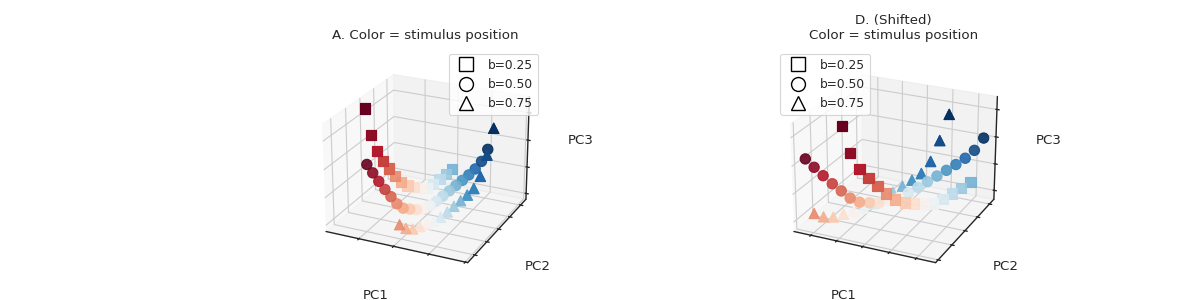

In [8]:
shared_cmap = plt.cm.RdBu

# legend: swatch at the boundary value on the global stim scale
legend_handles_shared = [
    Line2D([0], [0], marker=cond_markers[bound], color='w',
           markerfacecolor='white', markeredgecolor='black', markersize=10,
           label=f'b={bound:.2f}')
    for bound in boundaries
]

def get_cond_df(bound, sort_col='stim'):
    # return pca_df[(pca_df['boundary'] == bound) & pca_df['stim'].between(stim_lo, stim_hi)].sort_values(sort_col)
    return pca_df[pca_df['boundary'] == bound].sort_values(sort_col)

# plot raw PCA, shared RdBu_r
fig = plt.figure(figsize=(12, 3))

# Plot 1: Raw PCA
ax = fig.add_subplot(121, projection='3d')
for bound in boundaries:
    cond_df = get_cond_df(bound)
    colors = shared_cmap(shared_norm(cond_df['stim'].values))
    ax.scatter(cond_df['PC1'], cond_df['PC2'], cond_df['PC3'], c=colors, s=55, alpha=0.9, marker=cond_markers[bound])
ax.set_title('A. Color = stimulus position')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.view_init(elev=view_elev, azim=view_azim)
ax.legend(handles=legend_handles_shared, loc='best')

# Plot 2: PC-centroid-subtracted
ax = fig.add_subplot(122, projection='3d')
for bound in boundaries:
    cond_df = get_cond_df(bound)
    colors = shared_cmap(shared_norm(cond_df['stim'].values))
    ax.scatter(cond_df['PC1_pcc'], cond_df['PC2_pcc'], cond_df['PC3_pcc'], c=colors, s=55, alpha=0.9, marker=cond_markers[bound])
# ax.set_title('PC-centroid-subtracted\nColor = stimulus position')
ax.set_title('D. (Shifted)\nColor = stimulus position')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.view_init(elev=view_elev, azim=view_azim)
ax.legend(handles=legend_handles_shared, loc='best')

plt.tight_layout()
plt.show()

### PCA on aligned-stim

In [9]:
# === stim_aligned (relative to boundary) coloring with diverging colormap ===

# merge stim_aligned from beh_df into pca_df
pca_df['stim_aligned'] = beh_df.loc[pca_df.index, 'stim_aligned'].values

# symmetric norm for stim_aligned (diverging colormap: red=below boundary, blue=above)
stim_aligned_abs_max = max(abs(pca_df['stim_aligned'].min()), abs(pca_df['stim_aligned'].max()))
shared_norm_aligned = Normalize(vmin=-stim_aligned_abs_max, vmax=stim_aligned_abs_max)
shared_cmap_aligned = plt.cm.RdBu

print(f'stim_aligned range: [{pca_df["stim_aligned"].min():.4f}, {pca_df["stim_aligned"].max():.4f}]')

stim_aligned range: [-0.4643, 0.4643]


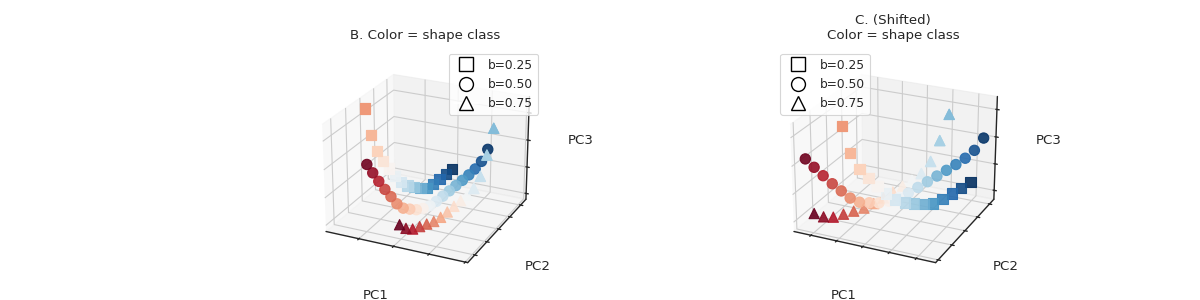

In [10]:
# plot raw PCA, stim_aligned colored (diverging RdBu_r)
fig = plt.figure(figsize=(12, 3))

# Plot 1: Raw PCA
ax = fig.add_subplot(121, projection='3d')
for bound in boundaries:
    cond_df = get_cond_df(bound)
    colors = shared_cmap_aligned(shared_norm_aligned(cond_df['stim_aligned'].values))
    ax.scatter(cond_df['PC1'], cond_df['PC2'], cond_df['PC3'], c=colors, s=55, alpha=0.9, marker=cond_markers[bound])
ax.set_title('B. Color = shape class')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.view_init(elev=view_elev, azim=view_azim)
ax.legend(handles=legend_handles_shared, loc='best')

# Plot 2: PC-centroid-subtracted
ax = fig.add_subplot(122, projection='3d')
for bound in boundaries:
    cond_df = get_cond_df(bound)
    colors = shared_cmap_aligned(shared_norm_aligned(cond_df['stim_aligned'].values))
    ax.scatter(cond_df['PC1_pcc'], cond_df['PC2_pcc'], cond_df['PC3_pcc'], c=colors, s=55, alpha=0.9, marker=cond_markers[bound])
# ax.set_title('Centroid-subtracted\n(stim rel. to boundary)')
ax.set_title('C. (Shifted)\nColor = shape class')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.view_init(elev=view_elev, azim=view_azim)
ax.legend(handles=legend_handles_shared, loc='best')

plt.tight_layout()
plt.show()

## Procrustes align

In [11]:
# --- Procrustes alignment and meganet construction ---
from scipy.linalg import orthogonal_procrustes

stim = pca_df['stim'].values
boundary = pca_df['boundary'].values
mask_mid = stim != 0.5
mask_bound = stim != boundary

# Unaligned meganets
n_nets, n_trials, n_units = hidden_stack.shape
X_meganet_mid = hidden_stack[:, mask_mid, :].reshape(-1, n_units)
y_meganet_mid = np.tile((stim[mask_mid] > 0.5).astype(int), n_nets)
X_meganet_bound = hidden_stack[:, mask_bound, :].reshape(-1, n_units)
y_meganet_bound = np.tile((stim[mask_bound] > boundary[mask_bound]).astype(int), n_nets)

# Procrustes alignment (using mean as reference)
ref_mid = hidden_stack[:, mask_mid, :].mean(axis=0)
ref_bound = hidden_stack[:, mask_bound, :].mean(axis=0)

aligned_nets_mid = []
for net in range(n_nets):
    X = hidden_stack[net, mask_mid, :]
    R, _ = orthogonal_procrustes(X, ref_mid)
    aligned_nets_mid.append(X @ R)
X_meganet_mid_aligned = np.vstack(aligned_nets_mid)

aligned_nets_bound = []
for net in range(n_nets):
    X = hidden_stack[net, mask_bound, :]
    R, _ = orthogonal_procrustes(X, ref_bound)
    aligned_nets_bound.append(X @ R)
X_meganet_bound_aligned = np.vstack(aligned_nets_bound)


### 2. Cross-context midpoint decoding (unaligned meganet)
Decode stim > 0.5 vs. < 0.5 using the unaligned meganet.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

clf = LogisticRegression(max_iter=1000)
scores = cross_val_score(clf, X_meganet_mid, y_meganet_mid, cv=5)
print(f"Unaligned meganet mid-point decoding: {scores.mean():.3f} ± {scores.std():.3f}")


Unaligned meganet mid-point decoding: 0.608 ± 0.042


### 3. Cross-context classification (boundary dependent, unaligned meganet)
Decode stim > boundary vs. < boundary using the unaligned meganet.

In [13]:
clf = LogisticRegression(max_iter=1000)
scores = cross_val_score(clf, X_meganet_bound, y_meganet_bound, cv=5)
print(f"Unaligned meganet boundary classification: {scores.mean():.3f} ± {scores.std():.3f}")


Unaligned meganet boundary classification: 0.584 ± 0.032


### 4. Cross-context midpoint decoding (aligned meganet)
Decode stim > 0.5 vs. < 0.5 using the Procrustes-aligned meganet.

In [14]:
clf = LogisticRegression(max_iter=1000)
scores = cross_val_score(clf, X_meganet_mid_aligned, y_meganet_mid, cv=5)
print(f"Aligned meganet mid-point decoding: {scores.mean():.3f} ± {scores.std():.3f}")


Aligned meganet mid-point decoding: 0.931 ± 0.018


### 5. Cross-context classification (boundary dependent, aligned meganet)
Decode stim > boundary vs. < boundary using the Procrustes-aligned meganet.

In [15]:
clf = LogisticRegression(max_iter=1000)
scores = cross_val_score(clf, X_meganet_bound_aligned, y_meganet_bound, cv=5)
print(f"Aligned meganet boundary classification: {scores.mean():.3f} ± {scores.std():.3f}")


Aligned meganet boundary classification: 0.906 ± 0.030
